# Notebook 06 - Evaluation finale
Evaluation unique sur le test set, courbes ROC et Precision-Recall, distribution
des probabilites, optimisation du seuil sur validation et comparaison aux objectifs.


In [1]:
import sys
from datetime import datetime, timezone
from pathlib import Path
ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from src.features import RAW_INPUT_FEATURES


In [2]:
def metrics_at_threshold(y_true, probabilities, decision_threshold, fn_cost=10, fp_cost=1):
    predictions = (probabilities >= decision_threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, predictions, labels=[0, 1]).ravel()
    return {
        'accuracy': round(accuracy_score(y_true, predictions), 4),
        'precision': round(precision_score(y_true, predictions, zero_division=0), 4),
        'recall': round(recall_score(y_true, predictions, zero_division=0), 4),
        'f1': round(f1_score(y_true, predictions, zero_division=0), 4),
        'roc_auc': round(roc_auc_score(y_true, probabilities), 4),
        'pr_auc': round(average_precision_score(y_true, probabilities), 4),
        'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp),
        'business_cost': int(fn_cost * fn + fp_cost * fp),
    }

tuned_artifact = joblib.load(ROOT / 'models' / 'tuned_model.joblib')
model = tuned_artifact['pipeline']
validation = pd.read_csv(ROOT / 'data' / 'processed' / 'validation.csv')
test = pd.read_csv(ROOT / 'data' / 'processed' / 'test.csv')
X_validation, y_validation = validation.drop(columns='bad_nutrition'), validation['bad_nutrition'].astype(int)
X_test, y_test = test.drop(columns='bad_nutrition'), test['bad_nutrition'].astype(int)

validation_prob = model.predict_proba(X_validation)[:, 1]
threshold_rows = []
for candidate in np.round(np.arange(0.10, 0.91, 0.01), 2):
    threshold_rows.append({'threshold': candidate, **metrics_at_threshold(y_validation, validation_prob, candidate)})
thresholds = pd.DataFrame(threshold_rows)
thresholds.to_csv(ROOT / 'models' / 'threshold_optimization.csv', index=False)
best = thresholds.sort_values(['business_cost', 'f1'], ascending=[True, False]).iloc[0]
threshold = float(best['threshold'])

prob = model.predict_proba(X_test)[:, 1]
pred_default = (prob >= 0.5).astype(int)
pred_optimal = (prob >= threshold).astype(int)
metrics_default = metrics_at_threshold(y_test, prob, 0.5)
metrics_optimal = metrics_at_threshold(y_test, prob, threshold)
display(pd.DataFrame({
    'seuil_0.5': metrics_default,
    f'seuil_optimal_{threshold}': metrics_optimal,
}))


,seuil_0.5,seuil_optimal_0.1
accuracy,0.9595,0.9463
precision,0.8727,0.7835
recall,0.8992,0.9563
f1,0.8858,0.8613
roc_auc,0.9880,0.9880
pr_auc,0.9573,0.9573
tn,2421.0000,2351.0000
fp,69.0000,139.0000
fn,53.0000,23.0000
tp,473.0000,503.0000


## Courbes ROC, Precision-Recall et distribution des probabilites


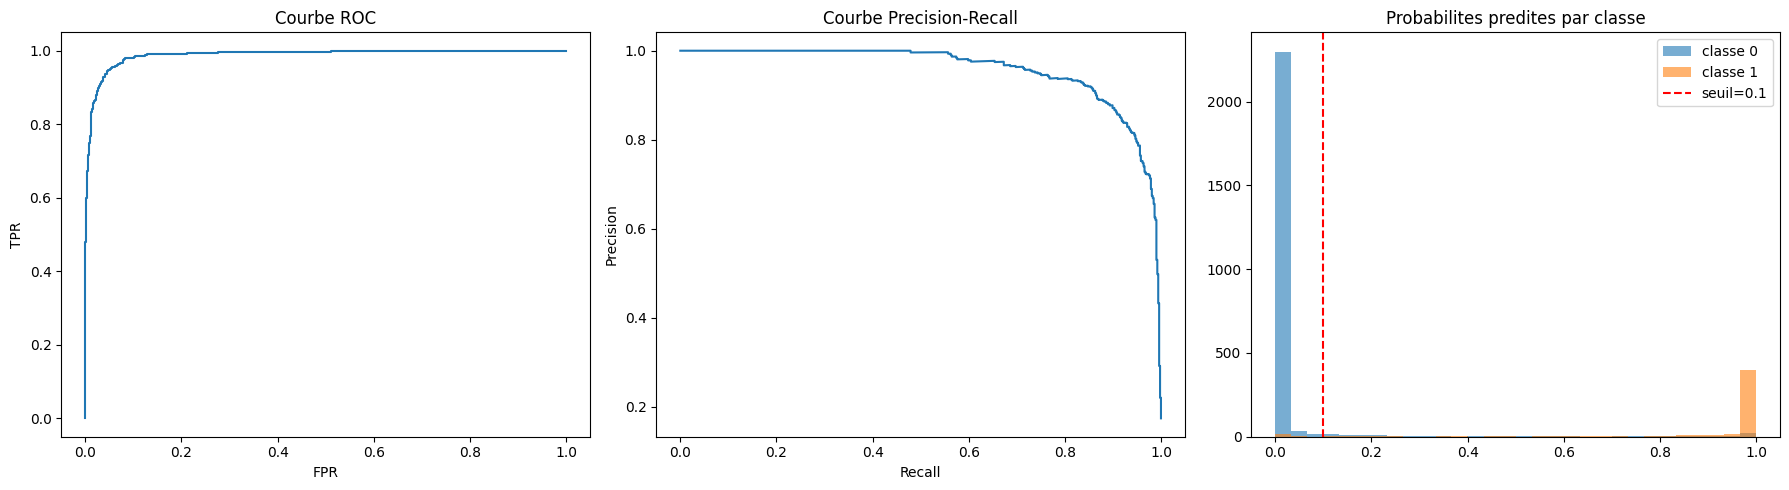

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fpr, tpr, _ = roc_curve(y_test, prob)
precision, recall, _ = precision_recall_curve(y_test, prob)
axes[0].plot(fpr, tpr); axes[0].set_title('Courbe ROC'); axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[1].plot(recall, precision); axes[1].set_title('Courbe Precision-Recall'); axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[2].hist(prob[y_test == 0], bins=30, alpha=.6, label='classe 0')
axes[2].hist(prob[y_test == 1], bins=30, alpha=.6, label='classe 1')
axes[2].axvline(threshold, color='red', linestyle='--', label=f'seuil={threshold}')
axes[2].set_title('Probabilites predites par classe'); axes[2].legend()
plt.tight_layout()
plt.show()


## Optimisation du seuil sur validation selon FN x 10 + FP x 1


threshold           0.1000
accuracy            0.9519
precision           0.8032
recall              0.9602
f1                  0.8747
roc_auc             0.9917
pr_auc              0.9684
tn               2365.0000
fp                124.0000
fn                 21.0000
tp                506.0000
business_cost     334.0000
Name: 0, dtype: float64

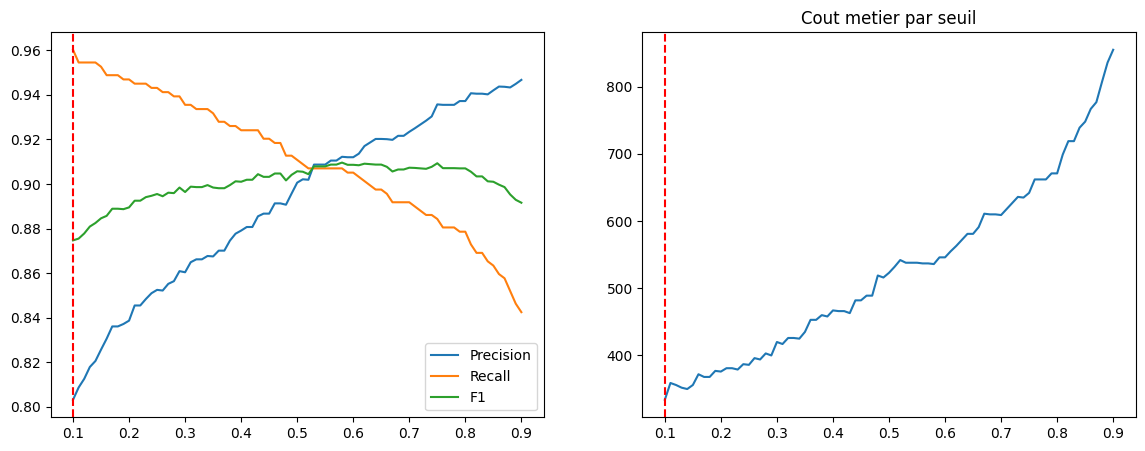

In [4]:
display(best)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(thresholds.threshold, thresholds.precision, label='Precision')
axes[0].plot(thresholds.threshold, thresholds.recall, label='Recall')
axes[0].plot(thresholds.threshold, thresholds.f1, label='F1')
axes[0].axvline(threshold, color='red', linestyle='--'); axes[0].legend()
axes[1].plot(thresholds.threshold, thresholds.business_cost)
axes[1].axvline(threshold, color='red', linestyle='--')
axes[1].set_title('Cout metier par seuil')
plt.show()


## Matrices de confusion et interpretation metier


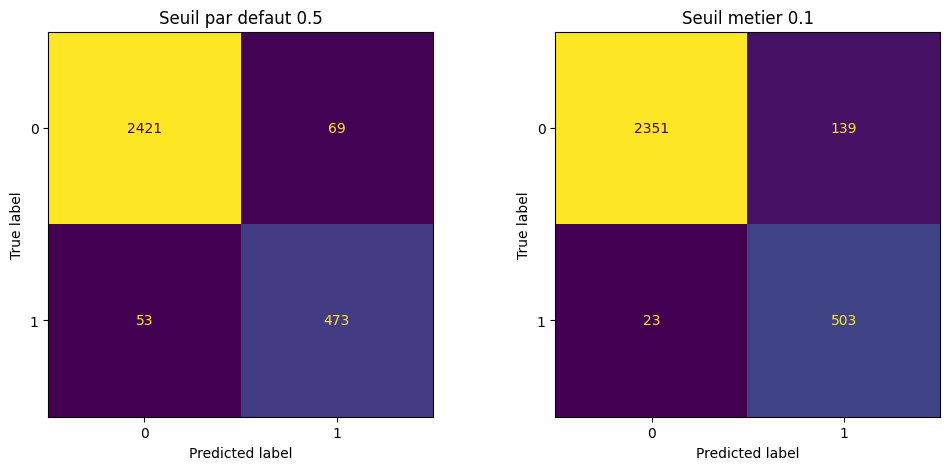

TP: mauvais produits detectes; FN: mauvais produits manques; FP: fausses alertes; TN: produits acceptables correctement identifies.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, pred_default)).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Seuil par defaut 0.5')
ConfusionMatrixDisplay(confusion_matrix(y_test, pred_optimal)).plot(ax=axes[1], colorbar=False)
axes[1].set_title(f'Seuil metier {threshold}')
plt.show()
print('TP: mauvais produits detectes; FN: mauvais produits manques; FP: fausses alertes; TN: produits acceptables correctement identifies.')


## Comparaison aux objectifs fixes en Phase 1


In [6]:
objectives = pd.DataFrame([
    {'objectif': 'Recall >= 0.75', 'resultat': metrics_optimal['recall'], 'atteint': metrics_optimal['recall'] >= .75},
    {'objectif': 'Precision >= 0.50', 'resultat': metrics_optimal['precision'], 'atteint': metrics_optimal['precision'] >= .50},
    {'objectif': 'F1 >= 0.60', 'resultat': metrics_optimal['f1'], 'atteint': metrics_optimal['f1'] >= .60},
    {'objectif': 'PR-AUC a maximiser', 'resultat': metrics_optimal['pr_auc'], 'atteint': True},
])
display(objectives)

dataset = pd.read_csv(ROOT / 'data' / 'dataset.csv')
artifact = {
    'pipeline': model,
    'threshold': threshold,
    'model_version': '2.0.0',
    'trained_at': datetime.now(timezone.utc).isoformat(),
    'metrics_default_threshold': metrics_default,
    'metrics_optimal_threshold': metrics_optimal,
    'cost_config': {'fn_cost': 10, 'fp_cost': 1},
    'best_params': tuned_artifact['best_params'],
    'cv_results': {
        'baseline_f1_mean': round(tuned_artifact['baseline_f1_mean'], 4),
        'tuned_f1_mean': round(tuned_artifact['tuned_f1_mean'], 4),
    },
    'imbalance_strategy': tuned_artifact['imbalance_strategy'],
    'raw_input_features': RAW_INPUT_FEATURES,
    'allowed_categories': {
        'main_category': sorted(dataset['main_category'].dropna().astype(str).unique().tolist()),
        'country': sorted(dataset['country'].dropna().astype(str).unique().tolist()),
    },
}
joblib.dump(artifact, ROOT / 'models' / 'final_model.joblib')
print('Modele final, seuil et metadonnees serialises dans models/final_model.joblib')


,objectif,resultat,atteint
0,Recall >= 0.75,0.9563,True
1,Precision >= 0.50,0.7835,True
2,F1 >= 0.60,0.8613,True
3,PR-AUC a maximiser,0.9573,True


Modele final, seuil et metadonnees serialises dans models/final_model.joblib


## Synthese
Tous les objectifs quantifies de Phase 1 sont atteints. Le seuil metier reduit
le cout asymetrique en diminuant les faux negatifs, au prix de davantage de
fausses alertes acceptables.
